In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import beta
import warnings
from bayesiandematel import ScoreEstimator, ScoreLikelihood
import statsmodels.api as sm
from statsmodels.miscmodels.ordinal_model import OrderedModel
warnings.filterwarnings("ignore", "is_categorical_dtype")
warnings.filterwarnings("ignore", "use_inf_as_na")

In [4]:
def generate_sample_responses(n):
    values = [1, 2, 3, 4, 5]
    p = [0.1, 0.15, 0.2, 0.4, 0.15]
    samples = np.random.choice(values, size=n, p=p)
    return samples

In [5]:
n_samples = 100
Y = generate_sample_responses(n_samples)

In [6]:
# 1. Prepare your data (ensure it's an ordered category)
# Replace this with your actual data
y = pd.Series(Y, dtype="category")
y = y.cat.reorder_categories([1,2,3,4,5], ordered=True)

# 2. Initialize with exog=None
# This tells statsmodels there are no predictors, only thresholds
mod = OrderedModel(y, None, distr='probit')

# 3. Fit the model
res = mod.fit(method='bfgs', disp=False)

print(res.summary())

                             OrderedModel Results                             
Dep. Variable:                      y   Log-Likelihood:                -147.00
Model:                   OrderedModel   AIC:                             302.0
Method:            Maximum Likelihood   BIC:                             312.4
Date:                Sat, 04 Apr 2026                                         
Time:                        07:14:29                                         
No. Observations:                 100                                         
Df Residuals:                      96                                         
Df Model:                           0                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
1/2           -1.2816      0.171     -7.497      0.000      -1.617      -0.947
2/3           -0.5530      0.247     -2.236      0.0

### The Score as a Random Variable with a Beta Distribution
The pdf is given by $X\sim \text{Beta}(\alpha,\beta)$\
$\alpha_k = \frac{k-1}{4}(\kappa-2)+1$\
$\beta_k = \left(1-\frac{k-1}{4}\right)(\kappa-2)+1$\
where $k\in \{1,2,3,4,5\}$ and $\kappa>2$ is a free parameter that dictates how concentrated that distribution is at $k$\
$Y = 1 + 4X$\
$f(Y) = $

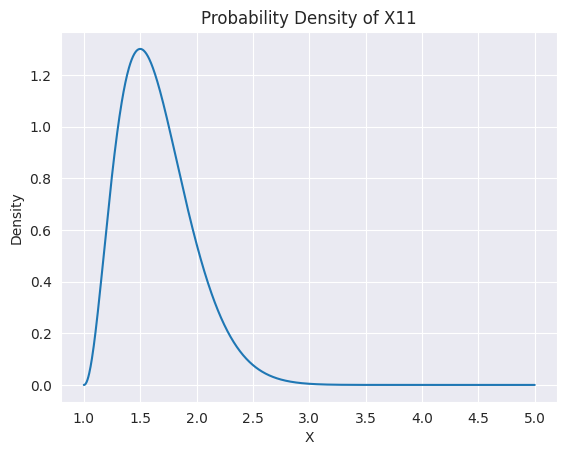

In [11]:
X_11 = ScoreEstimator(1.5, 20, label="X11")
X_11.plot_pdf()